# Alarm data

**Requires internet:** the "Baseline" section near the end fetches the true
ALARM network from the bnlearn repository via `pgmpy.utils.get_example_model`.
Everything above it runs offline from the packaged dataset.

In [1]:
import random
import time

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq

import pandas as pd
import cslearn.scoring as sc
import cslearn.learning as ctl
import cslearn.ldag as ldag
import numpy as np

%load_ext autoreload
%autoreload 2

/home/alex/projects/cstrees/code/.devenv/state/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read data

In [2]:
# Load the packaged copy of the ALARM data (resolves regardless of the
# working directory the notebook is run from).
from importlib.resources import files
import cslearn.datasets

alarmdf = pd.read_csv(files(cslearn.datasets) / 'alarm.csv')
alarmdf = alarmdf.drop(columns=['Unnamed: 0'])
alarmdf.head()

,CVP,PCWP,HIST,TPR,BP,CO,HRBP,HREK,HRSA,PAP,...,ERLO,HR,ERCA,SHNT,PVS,ACO2,VALV,VLNG,VTUB,VMCH
0,NORMAL,NORMAL,False,LOW,NORMAL,HIGH,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,NORMAL,NORMAL,HIGH,LOW,ZERO,NORMAL
1,NORMAL,NORMAL,False,NORMAL,LOW,LOW,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,LOW,LOW,ZERO,ZERO,LOW,NORMAL
2,NORMAL,HIGH,False,NORMAL,NORMAL,HIGH,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,LOW,LOW,ZERO,ZERO,LOW,NORMAL
3,NORMAL,NORMAL,False,LOW,LOW,HIGH,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,NORMAL,LOW,ZERO,ZERO,LOW,NORMAL
4,NORMAL,NORMAL,False,LOW,LOW,NORMAL,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,LOW,LOW,ZERO,ZERO,LOW,NORMAL


Convert all the outcomes into numeric values.

In [3]:
alarmnp = alarmdf.to_numpy()
alarmnp[:,0] = [0 for i in range(20000)]

def convertToNumeric(df):
    npdf = df.to_numpy()
    vars = list(df.columns)
    n = len(df)
    for v in vars:
        j = vars.index(v)
        states = list(alarmdf[v].drop_duplicates().to_numpy())
        for i in range(n):
            npdf[i,j] = states.index(alarmdf[v].iloc[i])
    numdf = pd.DataFrame(npdf)
    return numdf

numalarmdf = convertToNumeric(alarmdf)

cards_row = {0 : 3, 1 : 3, 2 : 2, 3 : 3, 4 : 3, 5 : 3, 6 : 3, 7 : 3, 8 : 3, 9 : 3, 10 : 3, 11 : 2, 12 : 4, 13 : 4, 14 : 4, 15 : 3, 16 : 2, 17 : 2, 18 : 2, 19 : 2, 20 : 2, 21 : 3, 22 : 2, 23 : 2, 24 : 3, 25 : 3, 26 : 2, 27 : 2, 28 : 3, 29 : 2, 30 : 2, 31 : 3, 32 : 3, 33 : 4, 34 : 4, 35 : 4, 36 : 4}
numalarmdf.loc[len(numalarmdf)] = cards_row
target_row = 20000
# Move target row to first element of list.
idx = [target_row] + [i for i in range(len(numalarmdf)) if i != target_row]
numalarmdf.iloc[idx]
numalarmdf_cards = numalarmdf.iloc[idx].reset_index(drop=True)
numalarmdf_cards.columns = alarmdf.columns

## MCMC sampling

We run the PC algorithm to estimate a CPDAG that is used to restrict the possible context variables.

In [4]:
np.random.seed(1)
random.seed(1)
start = time.time()
pcgraph = pc(numalarmdf_cards[1:].values, 0.05, "chisq", node_names=numalarmdf_cards.columns)
poss_cvars = ctl.causallearn_graph_to_posscvars(pcgraph, labels=numalarmdf_cards.columns)
#print("Possible context variables per node:", poss_cvars)

score_table, context_scores, context_counts = sc.order_score_tables(numalarmdf_cards,
                                                                    max_cvars=2,
                                                                    alpha_tot=1.0,
                                                                    method="BDeu",
                                                                    poss_cvars=poss_cvars)

orders, scores = ctl.gibbs_order_sampler(5000, score_table)
print('Phase 1 (PC) + Phase 2 (Gibbs order sampler) time in seconds:', time.time() - start)

  0%|          | 0/37 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

Depth=0, working on node 0:   3%|▎         | 1/37 [00:00<00:00, 1989.71it/s]

Depth=0, working on node 1:   5%|▌         | 2/37 [00:00<00:00, 139.65it/s] 

Depth=0, working on node 2:   8%|▊         | 3/37 [00:00<00:00, 130.36it/s]

...

Gibbs order sampler:  89%|████████▉ | 4452/5000 [00:01<00:00, 2583.74it/s]

Gibbs order sampler:  94%|█████████▍| 4711/5000 [00:01<00:00, 2584.08it/s]

Gibbs order sampler:  99%|█████████▉| 4970/5000 [00:01<00:00, 2544.66it/s]

Gibbs order sampler: 100%|██████████| 5000/5000 [00:01<00:00, 2572.43it/s]

Phase 1 (PC) + Phase 2 (Gibbs order sampler) time in seconds: 5.439443588256836


In [5]:
# optimal variable ordering
alarmmaporder = orders[scores.index(max(scores))]
#print(alarmmaporder)

In [6]:
# Phase 3: exact staging search, given the MAP order. This cell produces the
# final learned CStree; `start` is still the timer from the Phase 1+2 cell,
# so this prints the end-to-end time for all three phases of Algorithm 1.
alarmopttree = ctl._optimal_cstree_given_order(alarmmaporder, context_scores)
print('Full pipeline (Phases 1-3) time in seconds:', time.time() - start)

Full pipeline (Phases 1-3) time in seconds: 5.5076282024383545


## LDAG representation

In [7]:
LDAG = alarmopttree.to_LDAG()

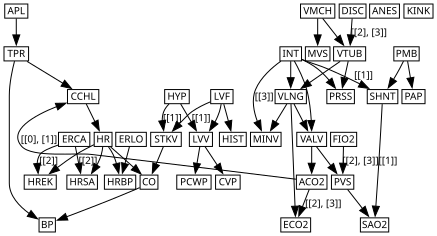

In [8]:
agraph = LDAG.plot_graphviz(
    nodesep="0.06", ranksep="0.1", margin="0.02,0.01",
    no_constraint_edges=[("ACO2", "CCHL")],
)
agraph.draw("source_alarm_ldag_repr_13_0.pdf")

# Losslessly crop to the drawing's ink bounding box (+3pt margin) by rewriting
# the page box in place -- no re-rendering, so the embedded 10pt font is
# untouched. Requires ghostscript on PATH (`nix-shell -p ghostscript` if not
# already available) and the `pikepdf` package.
import subprocess

import pikepdf


def crop_to_content(path, margin=3.0):
    result = subprocess.run(
        ["gs", "-q", "-dBATCH", "-dNOPAUSE", "-sDEVICE=bbox", path],
        capture_output=True, text=True, check=True,
    )
    line = [l for l in result.stderr.splitlines() if l.startswith("%%HiResBoundingBox:")][0]
    x0, y0, x1, y1 = (float(v) for v in line.split(":")[1].split())
    box = pikepdf.Array([x0 - margin, y0 - margin, x1 + margin, y1 + margin])
    pdf = pikepdf.open(path, allow_overwriting_input=True)
    pdf.pages[0].MediaBox = box
    pdf.pages[0].CropBox = box
    pdf.save(path)


crop_to_content("source_alarm_ldag_repr_13_0.pdf")
agraph

## Baseline: plain DAG (PC only), SHD vs. the true ALARM network

As a non-CSI baseline, we compare a plain DAG learned by PC alone (no CSlearn context-specific refinement) against the true ALARM network structure, and compare that SHD to the SHD of CSlearn's LDAG (converted from its learned CStree, as above) against the same ground truth.

The true ALARM network structure is fetched from the bnlearn repository via `pgmpy`; its node names are relabeled to the abbreviated variable codes used throughout this notebook (matching the descriptions in the accompanying variable table).

In [9]:
from pgmpy.utils import get_example_model
from cslearn.evaluate import shd_edges

# Maps bnlearn's full node names to the abbreviated codes used in this
# notebook (see the variable table in the paper's supplement for the
# descriptions).
long_to_abbrev = {
    "CVP": "CVP", "PCWP": "PCWP", "HISTORY": "HIST", "TPR": "TPR", "BP": "BP", "CO": "CO",
    "HRBP": "HRBP", "HREKG": "HREK", "HRSAT": "HRSA", "PAP": "PAP", "SAO2": "SAO2",
    "FIO2": "FIO2", "PRESS": "PRSS", "EXPCO2": "ECO2", "MINVOL": "MINV", "MINVOLSET": "MVS",
    "HYPOVOLEMIA": "HYP", "LVFAILURE": "LVF", "ANAPHYLAXIS": "APL", "INSUFFANESTH": "ANES",
    "PULMEMBOLUS": "PMB", "INTUBATION": "INT", "KINKEDTUBE": "KINK", "DISCONNECT": "DISC",
    "LVEDVOLUME": "LVV", "STROKEVOLUME": "STKV", "CATECHOL": "CCHL", "ERRLOWOUTPUT": "ERLO",
    "HR": "HR", "ERRCAUTER": "ERCA", "SHUNT": "SHNT", "PVSAT": "PVS", "ARTCO2": "ACO2",
    "VENTALV": "VALV", "VENTLUNG": "VLNG", "VENTTUBE": "VTUB", "VENTMACH": "VMCH",
}

true_alarm_model = get_example_model("alarm")
true_edges = {(long_to_abbrev[u], long_to_abbrev[v]) for u, v in true_alarm_model.edges()}
print(f"True ALARM network: {true_alarm_model.number_of_nodes()} nodes, {len(true_edges)} edges")

True ALARM network: 37 nodes, 46 edges


In [10]:
pc_dag_df = ctl.causallearn_graph_to_dag(pcgraph, labels=numalarmdf_cards.columns, alg="pc")
pc_edges = {(u, v) for u in pc_dag_df.index for v in pc_dag_df.columns if pc_dag_df.loc[u, v] == 1}

cslearn_edges = set(LDAG.edges())

pc_shd = shd_edges(pc_edges, true_edges)
cslearn_shd = shd_edges(cslearn_edges, true_edges)

print(f"PC-only DAG:   {len(pc_edges)} edges, SHD vs. true = {pc_shd}")
print(f"CSlearn's LDAG: {len(cslearn_edges)} edges, SHD vs. true = {cslearn_shd}")

TP = len(cslearn_edges & true_edges)
FP = len(cslearn_edges - true_edges)
n_nodes = true_alarm_model.number_of_nodes()
n_offdiag = n_nodes * n_nodes - n_nodes
TN = n_offdiag - TP - FP - len(true_edges - cslearn_edges)
accuracy = (TP + TN) / n_offdiag

print(f"CSlearn's LDAG: TP={TP}, FP={FP}")
print(f"CSlearn's LDAG: TP/{len(true_edges)}={TP/len(true_edges):.3f}, "
      f"FP/{len(true_edges)}={FP/len(true_edges):.3f}")
print(f"CSlearn's LDAG (unlabeled) accuracy: {accuracy:.3f}")

PC-only DAG:   44 edges, SHD vs. true = 5
CSlearn's LDAG: 42 edges, SHD vs. true = 5
CSlearn's LDAG: TP=41, FP=1
CSlearn's LDAG: TP/46=0.891, FP/46=0.022
CSlearn's LDAG (unlabeled) accuracy: 0.995


In [11]:
# Verify the manuscript's edge-label / CSI-relation counts against this run.
_, contexts = alarmopttree.to_LDAG(return_contexts=True)
n_labeled_edges = sum(1 for _, _, d in LDAG.edges(data=True) if d.get('label'))
n_csi_relations = sum(len(c) for c in contexts.values())
print(f"labeled edges: {n_labeled_edges}")
print(f"CSI relations: {n_csi_relations}")

labeled edges: 11
CSI relations: 15


In [12]:
# Human-readable dump of every labeled edge's CSI relations, for
# transcribing Table 'CSI relations learned for ALARM data set' in the
# paper's supplement.
state_names = {v: list(alarmdf[v].drop_duplicates().to_numpy()) for v in alarmdf.columns}
var_index = {v: i for i, v in enumerate(numalarmdf_cards.columns)}

for (u, v), relations in sorted(contexts.items()):
    lbl = LDAG.edges[u, v]['label']
    print(f"L_{{{var_index[u]},{var_index[v]}}} = {lbl}   ({u} -> {v})")
    for relation in relations:
        numeric = ' & '.join(f'X_{var_index[c]}={val}' for c, val in relation)
        named = ' & '.join(f'{c}={state_names[c][val]}' for c, val in relation)
        print(f"    X_{var_index[v]} indep X_{var_index[u]} | {numeric}   |   {v} indep {u} | {named}")

L_{32,26} = [[0], [1]]   (ACO2 -> CCHL)
    X_26 indep X_32 | X_3=0   |   CCHL indep ACO2 | TPR=LOW
    X_26 indep X_32 | X_3=1   |   CCHL indep ACO2 | TPR=NORMAL
L_{32,13} = [[2], [3]]   (ACO2 -> ECO2)
    X_13 indep X_32 | X_34=2   |   ECO2 indep ACO2 | VLNG=HIGH
    X_13 indep X_32 | X_34=3   |   ECO2 indep ACO2 | VLNG=NORMAL
L_{23,35} = [[2], [3]]   (DISC -> VTUB)
    X_35 indep X_23 | X_36=2   |   VTUB indep DISC | VMCH=LOW
    X_35 indep X_23 | X_36=3   |   VTUB indep DISC | VMCH=ZERO
L_{29,7} = [[2]]   (ERCA -> HREK)
    X_7 indep X_29 | X_28=2   |   HREK indep ERCA | HR=LOW
L_{29,8} = [[2]]   (ERCA -> HRSA)
    X_8 indep X_29 | X_28=2   |   HRSA indep ERCA | HR=LOW
L_{11,31} = [[2], [3]]   (FIO2 -> PVS)
    X_31 indep X_11 | X_33=2   |   PVS indep FIO2 | VALV=LOW
    X_31 indep X_11 | X_33=3   |   PVS indep FIO2 | VALV=NORMAL
L_{16,24} = [[1]]   (HYP -> LVV)
    X_24 indep X_16 | X_17=1   |   LVV indep HYP | LVF=True
L_{16,25} = [[1]]   (HYP -> STKV)
    X_25 indep X_16 | X_17=